# Logistic Regression: Binary
<h2 style="color:green" align="center">Would a person buy life insurance based on  one variable (age) using logistic regression</h2>

This is binary logistic regression problem as there are only two possible outcomes (person buys insurance or doesn't).  This example is a toy example to show logistic regression

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
%matplotlib inline

C:\Users\hi\AppData\Local\Temp\ipykernel_19812\2544774444.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## Data collection

In [2]:
df = pd.read_csv("insurance_data.csv")
print(df.head())

   age  bought_insurance
0   22                 0
1   25                 0
2   47                 1
3   52                 0
4   46                 1


## EDA

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               27 non-null     int64
 1   bought_insurance  27 non-null     int64
dtypes: int64(2)
memory usage: 560.0 bytes
None


In [4]:
print(df.describe())

             age  bought_insurance
count  27.000000         27.000000
mean   39.666667          0.518519
std    15.745573          0.509175
min    18.000000          0.000000
25%    25.000000          0.000000
50%    45.000000          1.000000
75%    54.500000          1.000000
max    62.000000          1.000000


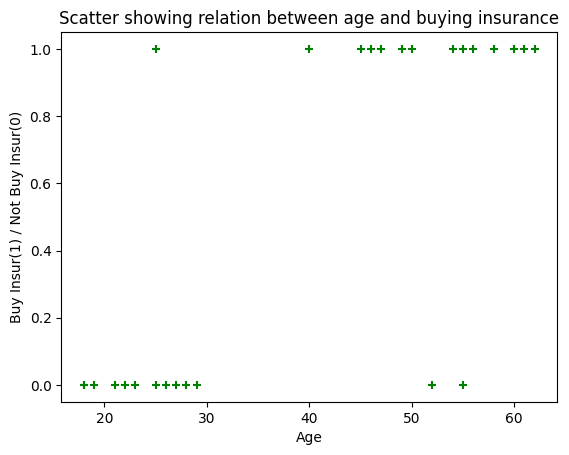

In [5]:
# Lets see how many people buy insurance based on age
plt.scatter(df.age,df.bought_insurance,marker='+',color='green')
# Labels and title
plt.xlabel("Age")
plt.ylabel("Buy Insur(1) / Not Buy Insur(0)")
plt.title("Scatter showing relation between age and buying insurance")
plt.show()

### Observation: Generally people over 40 buy insurance and younger people do not.
It follows a sigmoid function curve.

## Data Preprocessing and Feature Engg.

In [6]:
# check missing values
print(df.isnull().sum())

age                 0
bought_insurance    0
dtype: int64


GOOD. No missing values

## Split data into train and test

In [7]:
from sklearn.model_selection import train_test_split
X = df[['age']] # independant variable
y = df['bought_insurance'] # dependant variable, Label/Reponse variable

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

In [8]:
print(X_train.shape)
print(X_test.shape)

(21, 1)
(6, 1)


So 21 records are for training and 6 for testing. Not a huge dataset, but it would show proof of concept.

In [9]:
print(X_test)

    age
8    62
13   29
9    61
21   26
0    22
11   28


# Model training

In [10]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [11]:
model.fit(X_train, y_train) # This line of code would train your model

LogisticRegression()

## Model Evaluation
Lets make a prediction on one data point. Then we see how the model performs on the test dataset

In [12]:
# Lets see if s/o of age=25 would buy insurance
age = 25
age_2Darray = np.array([[age]])  # Convert to 2D array

probability = model.predict_proba(age_2Darray)[0, 1]  # Probability of buying insurance
print(f"Probability of buying insurance for age {age}: {probability:.2f}")

predicted_value = model.predict(age_2Darray)
print(f"Prediction for a {age}-year-old: {predicted_value[0]}")

Probability of buying insurance for age 25: 0.21
Prediction for a 25-year-old: 0


C:\Users\hi\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\hi\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [13]:
print(X_test)
print("#############")
print(y_test)

    age
8    62
13   29
9    61
21   26
0    22
11   28
#############
8     1
13    0
9     1
21    0
0     0
11    0
Name: bought_insurance, dtype: int64


In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)
print(f"y predicted: {y_pred}")

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

y predicted: [1 0 1 0 0 0]
Accuracy: 1.0


In [15]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



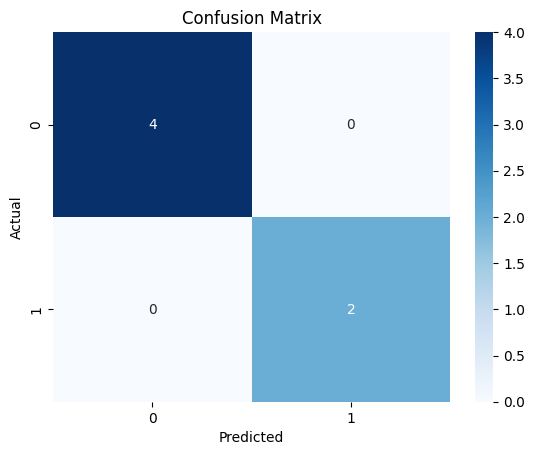

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Lets put the actual value and predicted values next to each other so we can see it better

In [17]:
# Create a DataFrame for better visualization
comparison_df = pd.DataFrame({'Actual': y_test, 
                              'Predicted': y_pred}
)

print(comparison_df)

    Actual  Predicted
8        1          1
13       0          0
9        1          1
21       0          0
0        0          0
11       0          0


In [18]:
model.predict_proba(X_test)

array([[0.05428672, 0.94571328],
       [0.7055532 , 0.2944468 ],
       [0.06039333, 0.93960667],
       [0.77084966, 0.22915034],
       [0.84096469, 0.15903531],
       [0.72848723, 0.27151277]])

### Above, 1st number is the prob of it being 0, and the 2nd number is prob of it being 1.

## Sigmoid curve
Lets generate sigmoid curve.

age_range: [18. 19. 20. 21. 22. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 31. 32. 33.
 34. 35. 36. 37. 38. 39. 40. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 49.
 50. 51. 52. 53. 54. 55. 56. 57. 58. 58. 59. 60. 61. 62.]
probabilities: [0.1073853  0.11871508 0.1310647  0.14448839 0.15903531 0.15903531
 0.17474764 0.19165854 0.20978992 0.22915034 0.24973277 0.27151277
 0.2944468  0.31847114 0.34350133 0.34350133 0.3694324  0.39613981
 0.4234813  0.45129955 0.47942556 0.5076826  0.53589064 0.56387089
 0.59145029 0.59145029 0.61846574 0.64476771 0.67022333 0.69471849
 0.71815931 0.74047264 0.76160582 0.78152588 0.80021806 0.80021806
 0.81768405 0.83393995 0.84901406 0.8629447  0.87577809 0.88756638
 0.89836581 0.90823519 0.91723447 0.91723447 0.92542368 0.93286191
 0.93960667 0.94571328]


C:\Users\hi\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


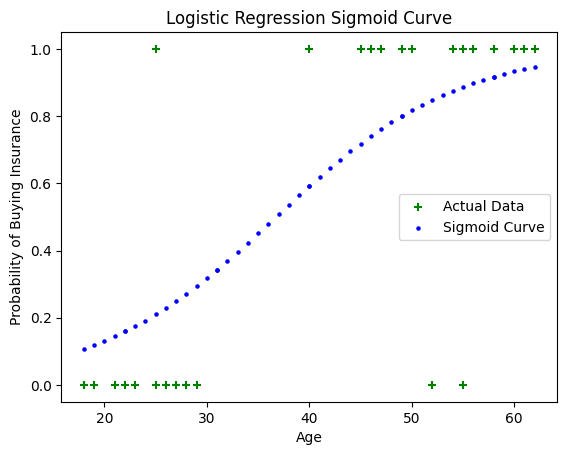

In [26]:
# Generate smooth age values for the sigmoid curve
age_range = np.linspace(df['age'].min(), df['age'].max(), 50).reshape(-1, 1)# create 50 ages
age_range = np.round(age_range,0)
print(f"age_range: {age_range.flatten()}")


# Predict probabilities using the trained model
probabilities = model.predict_proba(age_range)[:, 1]  # Probability of class 1, i.e. buying insurance
print(f"probabilities: {probabilities}") 

# Plot the scatter plot
plt.scatter(df['age'], df['bought_insurance'], marker='+', color='green', label="Actual Data")

# Plot the sigmoid curve(probability curve)
plt.scatter(age_range, probabilities, color='blue', s=5, label="Sigmoid Curve")

# Labels and title
plt.xlabel("Age")
plt.ylabel("Probability of Buying Insurance")
plt.title("Logistic Regression Sigmoid Curve")
plt.legend()
plt.show()


### Lets calculate the if a 25 year old person is going to buy insur ? 

In [20]:
age = 25
age_2Darray = np.array([[age]])  # Convert to 2D array

probability = model.predict_proba(age_2Darray)[0, 1]  # Probability of buying insurance
print(f"Probability of NOT buying insurance for age {age}: {1-probability:.2f}")
print(f"Probability of     buying insurance for age {age}: {probability:.2f}")

predicted_value = model.predict(age_2Darray)
print(f"Prediction for a {age}-year-old: {predicted_value[0]}")


Probability of NOT buying insurance for age 25: 0.79
Probability of     buying insurance for age 25: 0.21
Prediction for a 25-year-old: 0


C:\Users\hi\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\hi\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


He would NOT buy insurance because his probability of not buying is 0.79

## The Math
Lets see if the math predicts the same value.

![title](logistic_reg_formula.jpg)

Here p(X) is the probability that X belongs to a category
b0, b1 are the values that are found by logisticregression method above.

In [21]:
b0 = model.intercept_
b1 = model.coef_
print(b0)
print(b1)

[-4.15311919]
[[0.11307708]]


In [22]:
import math
def logistic_function(z):
  return math.exp(z) / (1 + math.exp(z))


z = b0 + b1*age
y = logistic_function(z)
print(f"prob of NOT buying: {1-y}") 
print(f"prob of     buying: {y}") 


prob of NOT buying: 0.7902100756755551
prob of     buying: 0.2097899243244449


C:\Users\hi\AppData\Local\Temp\ipykernel_19812\841692483.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return math.exp(z) / (1 + math.exp(z))


### Good . This value matches with above.